# LLM Watermark Robustness Analysis
## CSGS Hackathon 2026 — P4: AI Security

**Project:** How Robust Are LLM Watermarks? Evaluating Text Watermarking Under Paraphrase Attacks

This notebook runs the full experiment pipeline:
1. Generate watermarked and unwatermarked text using KGW scheme
2. Apply 4 types of removal attacks
3. Measure detection robustness across configurations
4. Evaluate security-utility tradeoff
5. Test ensemble defense countermeasure

**Make sure to set Runtime → Change runtime type → T4 GPU**

## 0. Setup & Installation

In [ ]:
# Install dependencies
!pip install -q torch transformers datasets scipy scikit-learn \
    matplotlib seaborn nltk bert-score rouge-score sentencepiece tqdm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.0 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np
import json
import os
import hashlib
import random
from typing import List, Dict, Tuple, Optional
from tqdm.notebook import tqdm
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Create output directories
os.makedirs('results/figures', exist_ok=True)
os.makedirs('results/tables', exist_ok=True)
os.makedirs('results/data', exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 1. Watermark Implementation (KGW Scheme)

In [ ]:
class WatermarkLogitsProcessor:
    """KGW green-list watermark (Kirchenbauer et al., ICML 2023)."""

    def __init__(self, vocab_size, gamma=0.25, delta=2.0, context_width=1, seed=42):
        self.vocab_size = vocab_size
        self.gamma = gamma
        self.delta = delta
        self.context_width = context_width
        self.seed = seed
        self.green_list_size = int(vocab_size * gamma)

    def _get_green_list(self, context_tokens):
        context_str = ",".join(str(t) for t in context_tokens)
        hash_val = hashlib.sha256(f"{self.seed}_{context_str}".encode()).hexdigest()
        position_seed = int(hash_val[:8], 16)
        rng = np.random.RandomState(position_seed)
        vocab_perm = rng.permutation(self.vocab_size)
        return torch.tensor(vocab_perm[:self.green_list_size], dtype=torch.long)

    def __call__(self, input_ids, scores):
        if input_ids.shape[1] < self.context_width:
            context = input_ids[0].tolist()
        else:
            context = input_ids[0, -self.context_width:].tolist()
        green_list = self._get_green_list(context)
        bias = torch.zeros(self.vocab_size, device=scores.device)
        bias[green_list] = self.delta
        return scores + bias


class WatermarkDetector:
    """Z-score based watermark detector."""

    def __init__(self, vocab_size, gamma=0.25, context_width=1, seed=42, z_threshold=4.0):
        self.vocab_size = vocab_size
        self.gamma = gamma
        self.context_width = context_width
        self.seed = seed
        self.z_threshold = z_threshold
        self.green_list_size = int(vocab_size * gamma)

    def _get_green_list(self, context_tokens):
        context_str = ",".join(str(t) for t in context_tokens)
        hash_val = hashlib.sha256(f"{self.seed}_{context_str}".encode()).hexdigest()
        position_seed = int(hash_val[:8], 16)
        rng = np.random.RandomState(position_seed)
        vocab_perm = rng.permutation(self.vocab_size)
        return set(vocab_perm[:self.green_list_size].tolist())

    def detect(self, token_ids):
        if len(token_ids) <= self.context_width:
            return {'z_score': 0.0, 'p_value': 1.0, 'green_count': 0,
                    'total_count': 0, 'green_fraction': 0.0,
                    'is_watermarked': False, 'per_token_green': []}

        green_count = 0
        total_count = 0
        per_token_green = []

        for i in range(self.context_width, len(token_ids)):
            context = token_ids[max(0, i - self.context_width):i]
            green_list = self._get_green_list(context)
            is_green = token_ids[i] in green_list
            per_token_green.append(is_green)
            if is_green:
                green_count += 1
            total_count += 1

        if total_count == 0:
            return {'z_score': 0.0, 'p_value': 1.0, 'green_count': 0,
                    'total_count': 0, 'green_fraction': 0.0,
                    'is_watermarked': False, 'per_token_green': per_token_green}

        expected = total_count * self.gamma
        std = np.sqrt(total_count * self.gamma * (1 - self.gamma))
        z_score = (green_count - expected) / std if std > 0 else 0.0
        p_value = 1 - stats.norm.cdf(z_score)

        return {
            'z_score': float(z_score),
            'p_value': float(p_value),
            'green_count': int(green_count),
            'total_count': int(total_count),
            'green_fraction': float(green_count / total_count),
            'is_watermarked': bool(z_score >= self.z_threshold),
            'per_token_green': per_token_green
        }

print('Watermark classes defined.')

Watermark classes defined.


## 2. Load Model & Dataset

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset

# --- Configuration ---
MODEL_NAME = 'facebook/opt-1.3b'  # Change to 'gpt2-large' if OOM
NUM_SAMPLES = 200
PROMPT_LENGTH = 30
GEN_LENGTH = 200

# Watermark configurations to test
CONFIGS = {
    'weak':          {'gamma': 0.50, 'delta': 1.0, 'context_width': 1},
    'moderate_low':  {'gamma': 0.25, 'delta': 2.0, 'context_width': 1},
    'moderate_high': {'gamma': 0.50, 'delta': 2.0, 'context_width': 1},
    'strong':        {'gamma': 0.25, 'delta': 4.0, 'context_width': 1},
    'moderate_ctx4': {'gamma': 0.25, 'delta': 2.0, 'context_width': 4},
    'strong_ctx4':   {'gamma': 0.25, 'delta': 4.0, 'context_width': 4},
}

print(f'Loading model: {MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map='auto'
)
model.eval()
VOCAB_SIZE = model.config.vocab_size
print(f'Model loaded. Vocab size: {VOCAB_SIZE}')

Loading model: facebook/opt-1.3b...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/653 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.63G [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

Model loaded. Vocab size: 50272


In [ ]:
# Load C4 prompts
print('Loading C4 dataset...')
dataset = load_dataset('allenai/c4', 'en', split='validation', streaming=True)

prompts = []
prompt_ids_list = []

for i, sample in enumerate(dataset):
    if len(prompts) >= NUM_SAMPLES:
        break
    text = sample['text']
    tokens = tokenizer(text, truncation=True, max_length=PROMPT_LENGTH + GEN_LENGTH)
    if len(tokens['input_ids']) >= PROMPT_LENGTH + 50:
        prompt_tok = tokens['input_ids'][:PROMPT_LENGTH]
        prompt_text = tokenizer.decode(prompt_tok, skip_special_tokens=True)
        prompts.append(prompt_text)
        prompt_ids_list.append(prompt_tok)

print(f'Loaded {len(prompts)} prompts.')
print(f'Example prompt: "{prompts[0][:80]}..."')

Loading C4 dataset...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Loaded 200 prompts.
Example prompt: "The woman who died after falling from a bridge over the A21 has been identified ..."


## 3. Generate Watermarked & Unwatermarked Text

In [ ]:
def generate_text(prompt_ids, watermark_processor=None, max_new_tokens=200):
    """Generate text with optional watermark."""
    input_ids = torch.tensor([prompt_ids]).to(model.device)
    generated = input_ids.clone()

    with torch.no_grad():
        for _ in range(max_new_tokens):
            outputs = model(generated)
            logits = outputs.logits[:, -1, :]

            if watermark_processor is not None:
                logits = watermark_processor(generated, logits)

            probs = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            generated = torch.cat([generated, next_token], dim=-1)

            if next_token.item() == tokenizer.eos_token_id:
                break

    return generated[0].tolist()

print('Generation function defined.')

Generation function defined.


In [ ]:
# Generate unwatermarked baseline
print('Generating unwatermarked (baseline) texts...')
unwatermarked_data = []

for i in tqdm(range(len(prompts))):
    output_ids = generate_text(prompt_ids_list[i], watermark_processor=None)
    gen_ids = output_ids[PROMPT_LENGTH:]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=True)

    unwatermarked_data.append({
        'index': i,
        'prompt': prompts[i],
        'generated_text': gen_text,
        'generated_ids': gen_ids,
        'watermarked': False
    })

print(f'Generated {len(unwatermarked_data)} unwatermarked texts.')

Generating unwatermarked (baseline) texts...


  0%|          | 0/200 [00:00<?, ?it/s]

Generated 200 unwatermarked texts.


In [ ]:
# Generate watermarked text for each configuration
all_watermarked = {}  # config_name -> list of results

for config_name, config in CONFIGS.items():
    print(f'\nGenerating watermarked text: {config_name} (gamma={config["gamma"]}, delta={config["delta"]}, h={config["context_width"]})')

    wp = WatermarkLogitsProcessor(
        vocab_size=VOCAB_SIZE,
        gamma=config['gamma'],
        delta=config['delta'],
        context_width=config['context_width']
    )

    results = []
    for i in tqdm(range(len(prompts))):
        output_ids = generate_text(prompt_ids_list[i], watermark_processor=wp)
        gen_ids = output_ids[PROMPT_LENGTH:]
        gen_text = tokenizer.decode(gen_ids, skip_special_tokens=True)

        results.append({
            'index': i,
            'prompt': prompts[i],
            'generated_text': gen_text,
            'generated_ids': gen_ids,
            'watermarked': True,
            'config': config_name
        })

    all_watermarked[config_name] = results
    print(f'  Done: {len(results)} texts generated.')

# Save checkpoint
torch.save({'unwatermarked': unwatermarked_data, 'watermarked': all_watermarked}, 'results/data/generated_texts.pt')
print('\nAll generation complete. Checkpoint saved.')


Generating watermarked text: weak (gamma=0.5, delta=1.0, h=1)


  0%|          | 0/200 [00:00<?, ?it/s]

  Done: 200 texts generated.

Generating watermarked text: moderate_low (gamma=0.25, delta=2.0, h=1)


  0%|          | 0/200 [00:00<?, ?it/s]

  Done: 200 texts generated.

Generating watermarked text: moderate_high (gamma=0.5, delta=2.0, h=1)


...

  Done: 200 texts generated.

Generating watermarked text: moderate_ctx4 (gamma=0.25, delta=2.0, h=4)


  0%|          | 0/200 [00:00<?, ?it/s]

  Done: 200 texts generated.

Generating watermarked text: strong_ctx4 (gamma=0.25, delta=4.0, h=4)


  0%|          | 0/200 [00:00<?, ?it/s]

  Done: 200 texts generated.

All generation complete. Checkpoint saved.


## 4. Experiment 1: Baseline Watermark Detectability

In [10]:
from sklearn.metrics import roc_curve, auc

# Detect watermark in all generated texts
detection_results = {}  # config_name -> {watermarked_z, unwatermarked_z, roc}

for config_name, config in CONFIGS.items():
    print(f'\nDetecting: {config_name}')

    detector = WatermarkDetector(
        vocab_size=VOCAB_SIZE,
        gamma=config['gamma'],
        context_width=config['context_width']
    )

    # Detect in watermarked texts
    wm_z_scores = []
    for item in all_watermarked[config_name]:
        result = detector.detect(item['generated_ids'])
        wm_z_scores.append(result['z_score'])

    # Detect in unwatermarked texts (should score low)
    uwm_z_scores = []
    for item in unwatermarked_data:
        result = detector.detect(item['generated_ids'])
        uwm_z_scores.append(result['z_score'])

    # Compute ROC
    labels = [1]*len(wm_z_scores) + [0]*len(uwm_z_scores)
    scores = wm_z_scores + uwm_z_scores
    fpr, tpr, _ = roc_curve(labels, scores)
    auroc = auc(fpr, tpr)
    tpr_at_1 = float(np.interp(0.01, fpr, tpr))

    detection_results[config_name] = {
        'wm_z_scores': wm_z_scores,
        'uwm_z_scores': uwm_z_scores,
        'fpr': fpr.tolist(),
        'tpr': tpr.tolist(),
        'auroc': auroc,
        'tpr_at_1pct_fpr': tpr_at_1
    }

    detected = sum(1 for z in wm_z_scores if z >= 4.0)
    print(f'  Mean WM z-score: {np.mean(wm_z_scores):.2f} | '
          f'Mean UWM z-score: {np.mean(uwm_z_scores):.2f} | '
          f'AUROC: {auroc:.4f} | TPR@1%FPR: {tpr_at_1:.4f} | '
          f'Detected: {detected}/{len(wm_z_scores)}')


Detecting: weak
  Mean WM z-score: 4.70 | Mean UWM z-score: 0.49 | AUROC: 0.9766 | TPR@1%FPR: 0.7750 | Detected: 140/200

Detecting: moderate_low
  Mean WM z-score: 11.18 | Mean UWM z-score: 0.55 | AUROC: 0.9998 | TPR@1%FPR: 0.9950 | Detected: 199/200

Detecting: moderate_high
  Mean WM z-score: 7.66 | Mean UWM z-score: 0.49 | AUROC: 0.9881 | TPR@1%FPR: 0.9300 | Detected: 177/200

Detecting: strong
  Mean WM z-score: 18.82 | Mean UWM z-score: 0.55 | AUROC: 0.9999 | TPR@1%FPR: 0.9950 | Detected: 199/200

Detecting: moderate_ctx4
  Mean WM z-score: 9.34 | Mean UWM z-score: 0.09 | AUROC: 0.9922 | TPR@1%FPR: 0.9700 | Detected: 187/200

Detecting: strong_ctx4
  Mean WM z-score: 16.84 | Mean UWM z-score: 0.09 | AUROC: 0.9934 | TPR@1%FPR: 0.9900 | Detected: 198/200


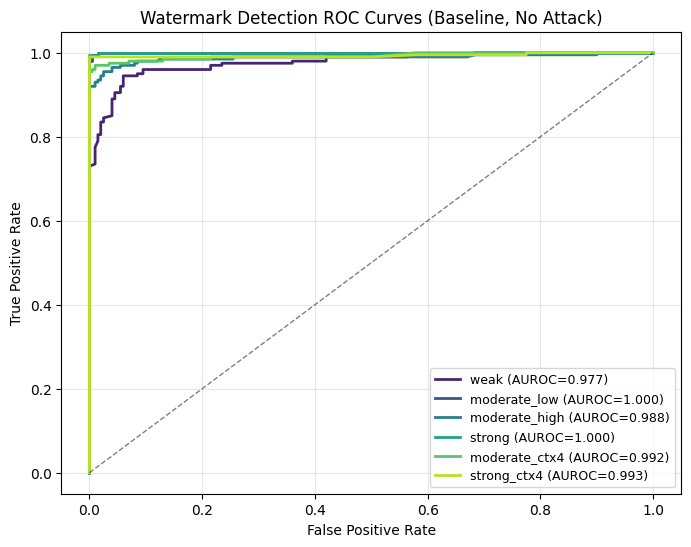

Figure 1 saved.


In [11]:
# FIGURE 1: ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(detection_results)))

for (name, data), color in zip(detection_results.items(), colors):
    ax.plot(data['fpr'], data['tpr'],
            label=f'{name} (AUROC={data["auroc"]:.3f})',
            color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Watermark Detection ROC Curves (Baseline, No Attack)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
fig.savefig('results/figures/fig1_roc_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

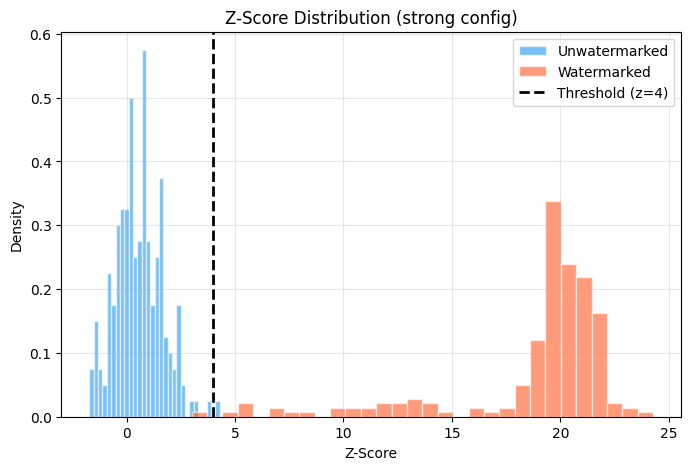

Figure 2 saved.


In [12]:
# FIGURE 2: Z-score distribution for best config
best_config = max(detection_results, key=lambda k: detection_results[k]['auroc'])
data = detection_results[best_config]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(data['uwm_z_scores'], bins=30, alpha=0.6, label='Unwatermarked',
        color='#2196F3', density=True, edgecolor='white')
ax.hist(data['wm_z_scores'], bins=30, alpha=0.6, label='Watermarked',
        color='#FF5722', density=True, edgecolor='white')
ax.axvline(x=4.0, color='black', linestyle='--', linewidth=2, label='Threshold (z=4)')
ax.set_xlabel('Z-Score')
ax.set_ylabel('Density')
ax.set_title(f'Z-Score Distribution ({best_config} config)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.savefig('results/figures/fig2_zscore_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

## 5. Implement Attacks

In [13]:
import nltk
from nltk.corpus import wordnet
import re

nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('punkt_tab', quiet=True)

def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('N'): return wordnet.NOUN
    elif tag.startswith('R'): return wordnet.ADV
    return None

def synonym_attack(text, fraction=0.3, seed=42):
    """Replace fraction of content words with synonyms."""
    random.seed(seed)
    words = nltk.word_tokenize(text)
    tagged = nltk.pos_tag(words)

    replaceable = []
    for i, (word, tag) in enumerate(tagged):
        if len(word) <= 2 or not word.isalpha():
            continue
        wn_pos = get_wordnet_pos(tag)
        if wn_pos is None:
            continue
        syns = set()
        for s in wordnet.synsets(word.lower(), pos=wn_pos):
            for l in s.lemmas():
                name = l.name().replace('_', ' ')
                if name.lower() != word.lower():
                    syns.add(name)
        if syns:
            replaceable.append((i, word, list(syns)))

    n = max(1, int(len(replaceable) * fraction))
    selected = random.sample(replaceable, min(n, len(replaceable)))

    result = words.copy()
    for idx, orig, syns in selected:
        rep = random.choice(syns)
        if orig[0].isupper(): rep = rep.capitalize()
        result[idx] = rep

    out = ' '.join(result)
    out = re.sub(r'\s+([,.!?;:])', r'\1', out)
    return out.strip()

print('Synonym attack defined.')

Synonym attack defined.


In [14]:
from transformers import AutoModelForSeq2SeqLM

# Load paraphrase model
PARA_MODEL = 'google/flan-t5-base'  # Use 'large' if GPU memory allows
print(f'Loading paraphrase model: {PARA_MODEL}...')
para_tokenizer = AutoTokenizer.from_pretrained(PARA_MODEL)
para_model = AutoModelForSeq2SeqLM.from_pretrained(
    PARA_MODEL, torch_dtype=torch.float16
).to(DEVICE)
para_model.eval()
print('Paraphrase model loaded.')

def llm_paraphrase_attack(text, max_length=512):
    """Paraphrase text using Flan-T5."""
    prompt = f'Paraphrase the following text while preserving its meaning. Use different words and sentence structures:\n\n{text}'
    inputs = para_tokenizer(prompt, return_tensors='pt', max_length=1024, truncation=True).to(DEVICE)
    with torch.no_grad():
        out = para_model.generate(**inputs, max_length=max_length, temperature=0.7,
                                   do_sample=True, top_p=0.9, num_beams=4,
                                   no_repeat_ngram_size=3)
    return para_tokenizer.decode(out[0], skip_special_tokens=True)

def sentence_rewrite_attack(text, max_length=512):
    """Aggressively rewrite text using Flan-T5."""
    prompt = f'Completely rewrite the following text using entirely different words, sentence structures, and writing style. Keep the same meaning:\n\n{text}'
    inputs = para_tokenizer(prompt, return_tensors='pt', max_length=1024, truncation=True).to(DEVICE)
    with torch.no_grad():
        out = para_model.generate(**inputs, max_length=max_length, temperature=0.9,
                                   do_sample=True, top_p=0.95,
                                   no_repeat_ngram_size=3)
    return para_tokenizer.decode(out[0], skip_special_tokens=True)

print('LLM paraphrase attacks defined.')

Loading paraphrase model: google/flan-t5-base...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Paraphrase model loaded.
LLM paraphrase attacks defined.


In [15]:
from transformers import MarianMTModel, MarianTokenizer

# Load translation models for back-translation
print('Loading translation models...')
en_fr_tok = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-en-fr')
en_fr_model = MarianMTModel.from_pretrained('Helsinki-NLP/opus-mt-en-fr').to(DEVICE)
fr_en_tok = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-fr-en')
fr_en_model = MarianMTModel.from_pretrained('Helsinki-NLP/opus-mt-fr-en').to(DEVICE)
print('Translation models loaded.')

def back_translation_attack(text):
    """EN -> FR -> EN back-translation."""
    # Chunk long text
    sentences = text.replace('. ', '.|').split('|')
    chunks, current = [], []
    for s in sentences:
        current.append(s)
        if len(' '.join(current).split()) > 80:
            chunks.append(' '.join(current))
            current = []
    if current:
        chunks.append(' '.join(current))

    result_chunks = []
    for chunk in chunks:
        # EN -> FR
        inp = en_fr_tok(chunk, return_tensors='pt', max_length=512, truncation=True, padding=True).to(DEVICE)
        with torch.no_grad():
            fr_ids = en_fr_model.generate(**inp, max_length=512, num_beams=4)
        fr_text = en_fr_tok.decode(fr_ids[0], skip_special_tokens=True)

        # FR -> EN
        inp2 = fr_en_tok(fr_text, return_tensors='pt', max_length=512, truncation=True, padding=True).to(DEVICE)
        with torch.no_grad():
            en_ids = fr_en_model.generate(**inp2, max_length=512, num_beams=4)
        en_text = fr_en_tok.decode(en_ids[0], skip_special_tokens=True)
        result_chunks.append(en_text)

    return ' '.join(result_chunks)

print('Back-translation attack defined.')

Loading translation models...


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Translation models loaded.
Back-translation attack defined.


## 6. Experiment 2: Attack Robustness

In [16]:
# Run all attacks on all configs
# We'll use the 'moderate_low' config as the primary evaluation target,
# then extend to others for the heatmap.

ATTACKS = {
    'no_attack': lambda text: text,
    'synonym_sub': lambda text: synonym_attack(text, fraction=0.3),
    'llm_paraphrase': llm_paraphrase_attack,
    'back_translation': back_translation_attack,
    'sentence_rewrite': sentence_rewrite_attack,
}

# Store attacked texts and their detection results
attack_results = {}  # config -> attack -> list of z-scores
attacked_texts_store = {}  # config -> attack -> list of texts

for config_name, config in CONFIGS.items():
    attack_results[config_name] = {}
    attacked_texts_store[config_name] = {}

    detector = WatermarkDetector(
        vocab_size=VOCAB_SIZE,
        gamma=config['gamma'],
        context_width=config['context_width']
    )

    for atk_name, atk_fn in ATTACKS.items():
        print(f'\n[{config_name}] Running attack: {atk_name}...')
        z_scores = []
        attacked_texts = []

        for item in tqdm(all_watermarked[config_name]):
            try:
                attacked = atk_fn(item['generated_text'])
            except Exception as e:
                attacked = item['generated_text']  # fallback on error

            attacked_texts.append(attacked)
            atk_ids = tokenizer(attacked, add_special_tokens=False)['input_ids']
            det = detector.detect(atk_ids)
            z_scores.append(det['z_score'])

        attack_results[config_name][atk_name] = z_scores
        attacked_texts_store[config_name][atk_name] = attacked_texts

        detected = sum(1 for z in z_scores if z >= 4.0)
        print(f'  Mean z: {np.mean(z_scores):.2f} | Detected: {detected}/{len(z_scores)}')

# Save checkpoint
torch.save({'attack_results': attack_results, 'attacked_texts': attacked_texts_store}, 'results/data/attack_results.pt')
print('\nAll attacks complete. Checkpoint saved.')


[weak] Running attack: no_attack...


  0%|          | 0/200 [00:00<?, ?it/s]

  Mean z: 4.65 | Detected: 139/200

[weak] Running attack: synonym_sub...


  0%|          | 0/200 [00:00<?, ?it/s]

  Mean z: 2.93 | Detected: 42/200

[weak] Running attack: llm_paraphrase...


...

  Mean z: 0.01 | Detected: 0/200

[strong_ctx4] Running attack: back_translation...


  0%|          | 0/200 [00:00<?, ?it/s]

  Mean z: 4.44 | Detected: 112/200

[strong_ctx4] Running attack: sentence_rewrite...


  0%|          | 0/200 [00:00<?, ?it/s]

  Mean z: -0.03 | Detected: 0/200

All attacks complete. Checkpoint saved.


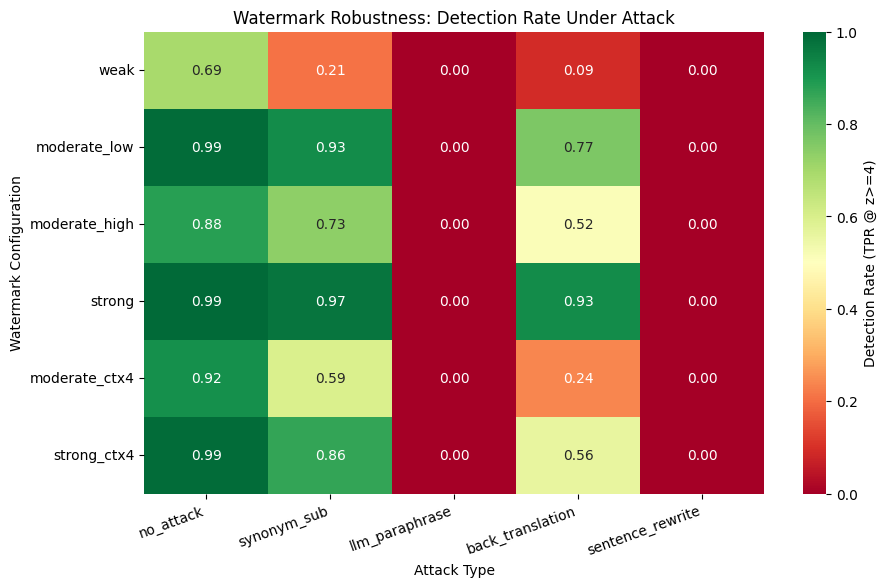

Figure 3 saved.


In [17]:
# FIGURE 3: Attack Robustness Heatmap
configs_list = list(CONFIGS.keys())
attacks_list = list(ATTACKS.keys())

heatmap_data = np.zeros((len(configs_list), len(attacks_list)))

for i, cfg in enumerate(configs_list):
    for j, atk in enumerate(attacks_list):
        z_scores = attack_results[cfg][atk]
        tpr = sum(1 for z in z_scores if z >= 4.0) / len(z_scores)
        heatmap_data[i, j] = tpr

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=attacks_list, yticklabels=configs_list,
            vmin=0, vmax=1, ax=ax,
            cbar_kws={'label': 'Detection Rate (TPR @ z>=4)'})
ax.set_xlabel('Attack Type')
ax.set_ylabel('Watermark Configuration')
ax.set_title('Watermark Robustness: Detection Rate Under Attack')
plt.xticks(rotation=20, ha='right')
fig.savefig('results/figures/fig3_attack_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

## 7. Experiment 3: Quality-Robustness Tradeoff

In [18]:
# Compute text quality: perplexity comparison between watermarked and unwatermarked
# Use GPT-2 as the oracle model

print('Loading GPT-2 for perplexity scoring...')
ppl_tokenizer = AutoTokenizer.from_pretrained('gpt2')
ppl_model = AutoModelForCausalLM.from_pretrained('gpt2').to(DEVICE)
ppl_model.eval()
if ppl_tokenizer.pad_token is None:
    ppl_tokenizer.pad_token = ppl_tokenizer.eos_token

def get_perplexity(text):
    enc = ppl_tokenizer(text, return_tensors='pt', truncation=True, max_length=512).to(DEVICE)
    with torch.no_grad():
        out = ppl_model(**enc, labels=enc['input_ids'])
    return torch.exp(out.loss).item()

# Compute perplexity for each config (sample first 50 for speed)
N_PPL = min(50, len(prompts))
quality_results = {}

# Unwatermarked baseline PPL
uwm_ppls = [get_perplexity(unwatermarked_data[i]['generated_text']) for i in tqdm(range(N_PPL), desc='UWM PPL')]
mean_uwm_ppl = np.mean(uwm_ppls)
print(f'Unwatermarked mean PPL: {mean_uwm_ppl:.2f}')

for config_name in CONFIGS:
    wm_ppls = [get_perplexity(all_watermarked[config_name][i]['generated_text']) for i in tqdm(range(N_PPL), desc=f'{config_name} PPL')]

    # Robustness = detection rate under strongest attack (LLM paraphrase)
    z_under_attack = attack_results[config_name].get('llm_paraphrase', attack_results[config_name]['synonym_sub'])
    robustness = sum(1 for z in z_under_attack if z >= 4.0) / len(z_under_attack)

    quality_results[config_name] = {
        'mean_ppl': float(np.mean(wm_ppls)),
        'ppl_overhead': float(np.mean(wm_ppls) - mean_uwm_ppl),
        'robustness': robustness
    }
    print(f'{config_name}: PPL={np.mean(wm_ppls):.2f} (overhead: {np.mean(wm_ppls)-mean_uwm_ppl:+.2f}) | Robustness: {robustness:.2f}')

Loading GPT-2 for perplexity scoring...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

strong: PPL=134.48 (overhead: +67.26) | Robustness: 0.00


moderate_ctx4 PPL:   0%|          | 0/50 [00:00<?, ?it/s]

moderate_ctx4: PPL=104.65 (overhead: +37.43) | Robustness: 0.00


strong_ctx4 PPL:   0%|          | 0/50 [00:00<?, ?it/s]

strong_ctx4: PPL=196.84 (overhead: +129.62) | Robustness: 0.00


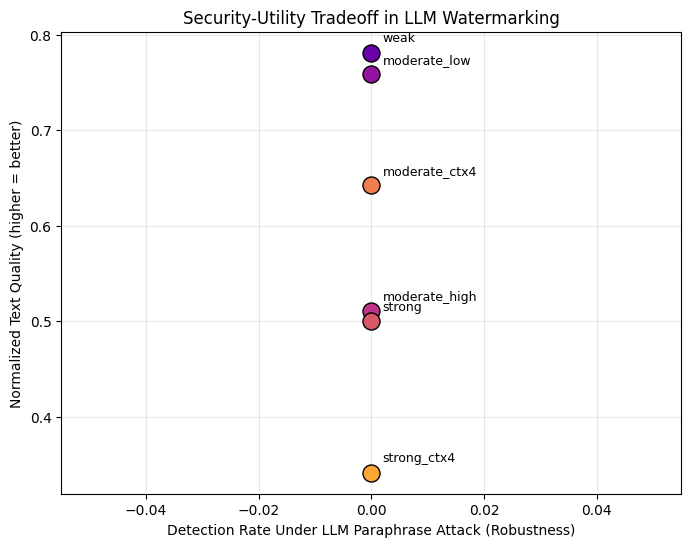

Figure 4 saved.


In [19]:
# FIGURE 4: Quality-Robustness Tradeoff
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(quality_results)))

for i, (name, data) in enumerate(quality_results.items()):
    # Quality = inverse of perplexity overhead (lower overhead = better quality)
    quality = 1.0 / (1.0 + data['ppl_overhead'] / mean_uwm_ppl)  # normalized
    ax.scatter(data['robustness'], quality, s=150, c=[colors[i]],
              edgecolors='black', linewidths=1, zorder=5)
    ax.annotate(name, (data['robustness'], quality),
               textcoords='offset points', xytext=(8, 8), fontsize=9)

ax.set_xlabel('Detection Rate Under LLM Paraphrase Attack (Robustness)')
ax.set_ylabel('Normalized Text Quality (higher = better)')
ax.set_title('Security-Utility Tradeoff in LLM Watermarking')
ax.grid(True, alpha=0.3)
fig.savefig('results/figures/fig4_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

## 8. Experiment 4: Ensemble Defense

In [20]:
# Ensemble detection: combine detectors with different context widths

class EnsembleDetector:
    def __init__(self, detectors, strategy='max_score'):
        self.detectors = detectors
        self.strategy = strategy

    def detect(self, token_ids, z_threshold=4.0):
        z_scores = [d.detect(token_ids)['z_score'] for d in self.detectors]

        if self.strategy == 'max_score':
            return max(z_scores)
        elif self.strategy == 'weighted_avg':
            return np.mean(z_scores)
        elif self.strategy == 'majority_vote':
            votes = sum(1 for z in z_scores if z >= z_threshold)
            return max(z_scores) if votes > len(self.detectors) / 2 else min(z_scores)
        return max(z_scores)

# Use the 'strong' config (gamma=0.25, delta=4.0) as the base
# Create ensemble with context widths 1, 2, 4
ensemble_detectors = [
    WatermarkDetector(VOCAB_SIZE, gamma=0.25, context_width=h)
    for h in [1, 2, 4]
]

ensemble = EnsembleDetector(ensemble_detectors, strategy='max_score')

# Compare single vs ensemble detection under attacks
# Use 'strong' config watermarked texts
single_detector = WatermarkDetector(VOCAB_SIZE, gamma=0.25, context_width=1)

comparison = {'single': {}, 'ensemble': {}}

for atk_name in ATTACKS:
    single_z, ensemble_z = [], []

    for item, atk_text in zip(all_watermarked['strong'], attacked_texts_store['strong'][atk_name]):
        atk_ids = tokenizer(atk_text, add_special_tokens=False)['input_ids']

        s_det = single_detector.detect(atk_ids)
        single_z.append(s_det['z_score'])

        e_z = ensemble.detect(atk_ids)
        ensemble_z.append(e_z)

    comparison['single'][atk_name] = sum(1 for z in single_z if z >= 4.0) / len(single_z)
    comparison['ensemble'][atk_name] = sum(1 for z in ensemble_z if z >= 4.0) / len(ensemble_z)

    print(f'{atk_name}: Single={comparison["single"][atk_name]:.3f} | Ensemble={comparison["ensemble"][atk_name]:.3f}')

no_attack: Single=0.995 | Ensemble=0.995
synonym_sub: Single=0.970 | Ensemble=0.970
llm_paraphrase: Single=0.000 | Ensemble=0.000
back_translation: Single=0.925 | Ensemble=0.930
sentence_rewrite: Single=0.000 | Ensemble=0.000


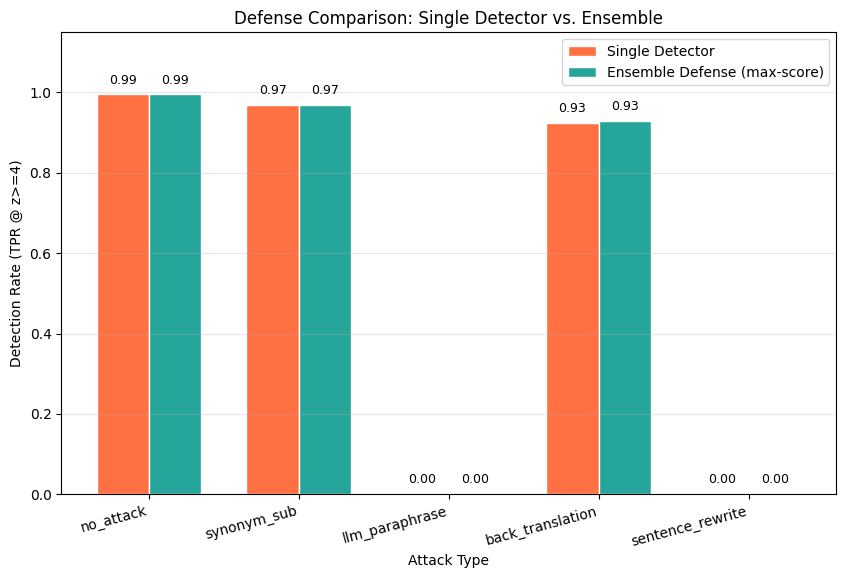

Figure 5 saved.


In [21]:
# FIGURE 5: Ensemble Defense Comparison
attacks_for_plot = list(ATTACKS.keys())
single_vals = [comparison['single'][a] for a in attacks_for_plot]
ensemble_vals = [comparison['ensemble'][a] for a in attacks_for_plot]

x = np.arange(len(attacks_for_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, single_vals, width, label='Single Detector',
               color='#FF7043', edgecolor='white')
bars2 = ax.bar(x + width/2, ensemble_vals, width, label='Ensemble Defense (max-score)',
               color='#26A69A', edgecolor='white')

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.2f}',
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.2f}',
            ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Attack Type')
ax.set_ylabel('Detection Rate (TPR @ z>=4)')
ax.set_title('Defense Comparison: Single Detector vs. Ensemble')
ax.set_xticks(x)
ax.set_xticklabels(attacks_for_plot, rotation=15, ha='right')
ax.legend()
ax.set_ylim([0, 1.15])
ax.grid(True, alpha=0.3, axis='y')
fig.savefig('results/figures/fig5_ensemble_defense.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

## 9. Results Summary Table

In [22]:
import pandas as pd

# Build summary table
rows = []
for cfg_name in CONFIGS:
    cfg = CONFIGS[cfg_name]
    row = {
        'Config': cfg_name,
        'gamma': cfg['gamma'],
        'delta': cfg['delta'],
        'h': cfg['context_width'],
        'AUROC': detection_results[cfg_name]['auroc'],
        'TPR@1%FPR': detection_results[cfg_name]['tpr_at_1pct_fpr'],
    }
    for atk_name in ATTACKS:
        z_scores = attack_results[cfg_name][atk_name]
        tpr = sum(1 for z in z_scores if z >= 4.0) / len(z_scores)
        row[f'TPR_{atk_name}'] = tpr

    if cfg_name in quality_results:
        row['PPL'] = quality_results[cfg_name]['mean_ppl']
        row['PPL_overhead'] = quality_results[cfg_name]['ppl_overhead']

    rows.append(row)

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv('results/tables/summary_results.csv', index=False)
print('\nSummary table saved to results/tables/summary_results.csv')

       Config  gamma  delta  h    AUROC  TPR@1%FPR  TPR_no_attack  TPR_synonym_sub  TPR_llm_paraphrase  TPR_back_translation  TPR_sentence_rewrite        PPL  PPL_overhead
         weak   0.50    1.0  1 0.976638      0.775          0.695            0.210                 0.0                 0.090                   0.0  86.036764     18.815297
 moderate_low   0.25    2.0  1 0.999850      0.995          0.990            0.925                 0.0                 0.765                   0.0  88.621094     21.399627
moderate_high   0.50    2.0  1 0.988100      0.930          0.880            0.735                 0.0                 0.515                   0.0 131.622292     64.400825
       strong   0.25    4.0  1 0.999925      0.995          0.995            0.970                 0.0                 0.925                   0.0 134.479098     67.257631
moderate_ctx4   0.25    2.0  4 0.992225      0.970          0.915            0.595                 0.0                 0.240                

## 10. Save All Results

In [23]:
# Save comprehensive results JSON
final_results = {
    'model': MODEL_NAME,
    'num_samples': NUM_SAMPLES,
    'configs': {k: v for k, v in CONFIGS.items()},
    'detection_aurocs': {k: v['auroc'] for k, v in detection_results.items()},
    'detection_tpr_at_1pct': {k: v['tpr_at_1pct_fpr'] for k, v in detection_results.items()},
    'attack_detection_rates': {},
    'quality': quality_results,
    'ensemble_comparison': comparison
}

for cfg in CONFIGS:
    final_results['attack_detection_rates'][cfg] = {}
    for atk in ATTACKS:
        z_scores = attack_results[cfg][atk]
        tpr = sum(1 for z in z_scores if z >= 4.0) / len(z_scores)
        final_results['attack_detection_rates'][cfg][atk] = tpr

with open('results/data/final_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print('All results saved!')
print('\nFigures in results/figures/')
print('Tables in results/tables/')
print('Data in results/data/')

All results saved!

Figures in results/figures/
Tables in results/tables/
Data in results/data/


## 11. Quick Demo (for presentation)

In [24]:
# Demo: show watermark in action on a single example
demo_idx = 0
demo_config = 'strong'
cfg = CONFIGS[demo_config]

demo_wm = all_watermarked[demo_config][demo_idx]
demo_uwm = unwatermarked_data[demo_idx]

detector = WatermarkDetector(VOCAB_SIZE, gamma=cfg['gamma'], context_width=cfg['context_width'])

wm_det = detector.detect(demo_wm['generated_ids'])
uwm_det = detector.detect(demo_uwm['generated_ids'])

print('='*60)
print('WATERMARK DEMO')
print('='*60)
print(f'\nPrompt: "{demo_wm["prompt"][:80]}..."')
print(f'\n--- Watermarked Text (z={wm_det["z_score"]:.2f}, p={wm_det["p_value"]:.2e}) ---')
print(demo_wm['generated_text'][:300] + '...')
print(f'\n--- Unwatermarked Text (z={uwm_det["z_score"]:.2f}, p={uwm_det["p_value"]:.2e}) ---')
print(demo_uwm['generated_text'][:300] + '...')

# Show attack effect
print(f'\n--- After LLM Paraphrase Attack ---')
attacked = attacked_texts_store[demo_config]['llm_paraphrase'][demo_idx]
atk_ids = tokenizer(attacked, add_special_tokens=False)['input_ids']
atk_det = detector.detect(atk_ids)
print(f'z-score: {wm_det["z_score"]:.2f} -> {atk_det["z_score"]:.2f}')
print(f'Detected: {wm_det["is_watermarked"]} -> {atk_det["is_watermarked"]}')
print(attacked[:300] + '...')

WATERMARK DEMO

Prompt: "The woman who died after falling from a bridge over the A21 has been identified ..."

--- Watermarked Text (z=19.69, p=0.00e+00) ---
 30, was pronounced dead on the scene at Hawburgh Bridge yesterday.
The bridge's staff told Cambridgeshire Constabulary they had not yet learned Ms Kendle's nationality but said it had happened when it had not been open to vehicle drivers and while closed to people on foot.
The dangerous bridge betw...

--- Unwatermarked Text (z=1.40, p=8.07e-02) ---
 61, was pronounced dead at the scene close to the Prince of Wales Bridge in Birmingham, West Midlands police said.
Police added: "The Major McClarkey investigation into Marta's death continues."
The weather in Birmingham on Friday was dry and bright with temperatures reaching into the high 20s.
It ...

--- After LLM Paraphrase Attack ---
z-score: 19.69 -> -0.24
Detected: True -> False
Police said in their investigations they cannot comment which type of motorbike could be attribuble 